# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2383 Миненок Алиса и Мордасов Евгений. Вариант №27.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

#### 1. Основные понятия
* **Генеральная совокупность** — всё множество возможных значений изучаемого признака или результатов наблюдений, которые могут быть получены при данных условиях.
* **Выборка** — часть генеральной совокупности, отобранная для проведения исследования. Для того чтобы результаты анализа можно было обобщить, выборка должна быть репрезентативной. Объем выборки обозначается как $n$.

#### 2. Ряды распределения
Процесс систематизации данных начинается с построения статистических рядов:
* **Ранжированный ряд** — расположение элементов выборки в порядке возрастания (или убывания). Разность между максимальным и минимальным значениями называется размахом выборки $W = x_{max} - x_{min}$.
* **Вариационный ряд** — последовательность попарно различных значений признака с указанием соответствующих им частот.

Для непрерывных признаков или при большом объеме выборки строится _интервальный ряд_. Область значений разбивается на $k$ частичных интервалов. Оптимальное число интервалов вычисляется по _формуле Стерджеса_:

$$k \approx 1 + 3.31 \lg(n)$$


Длина каждого интервала определяется как $h = \frac{W}{k}$.

#### 3. Частотные характеристики интервального ряда
Для анализа распределения данных по интервалам рассчитывается система частотных показателей:
* **Середина интервала** ($\tilde{x}_i$) — репрезентативное значение $i$-го интервала, вычисляемое как среднее арифметическое его границ.
* **Абсолютная частота** ($m_i$) — число вариант выборки, попавших в $i$-й интервал. Сумма всех абсолютных частот равна объему выборки: $\sum m_i = n$.
* **Относительная частота** ($\tilde{m}_i$) — отношение абсолютной частоты к общему объему выборки: $\tilde{m}_i = \frac{m_i}{n}$. Сумма относительных частот всегда равна $1$.
* **Накопленная абсолютная ($m_i^{нак}$) и относительная ($\tilde{m}_i^{нак}$) частоты** — суммы соответствующих частот для данного и всех предшествующих интервалов. Показывают количество (или долю) элементов выборки, значения которых не превышают верхнюю границу текущего интервала.

#### 4. Графическое представление
Для визуализации закономерностей варьирования признака применяются следующие графические формы:
1. **Полигон частот** — ломаная линия, соединяющая точки с координатами $(\tilde{x}_i, m_i)$ или $(\tilde{x}_i, \tilde{m}_i)$ в прямоугольной системе координат.
2. **Гистограмма** — ступенчатая фигура, состоящая из смежных прямоугольников, построенных на частичных интервалах. Высота прямоугольников пропорциональна соответствующим частотам ($m_i$ или $\tilde{m}_i$).
3. **Эмпирическая функция распределения (ЭФР)** — кумулятивная функция, построенная по накопленным относительным частотам $\tilde{m}_i^{нак}$. Она наглядно отражает процесс накопления частот по мере увеличения значений признака.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы




### Пункт 1. Выбор программного обеспечения
Для выполнения практической работы выбран язык программирования Python и среда Jupyter Notebook.

*Обоснование:* Python (с библиотеками `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`) является современным индустриальным стандартом для анализа данных и статистических вычислений. Jupyter Notebook позволяет удобно совмещать исполняемый код, математические формулы (LaTeX) и визуализацию в одном документе.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Пункт 2. Выбор генеральной совокупности
В качестве двумерной генеральной совокупности выбран открытый набор данных «2D Datasets» из репозитория платформы Kaggle.

* Источник данных: [Kaggle: 2D Datasets](https://www.kaggle.com/datasets/outsiders17711/2d-datasets)
* Обоснование выбора: Данная совокупность представляет собой массив двумерных координат (переменные X и Y). Подобные датасеты являются индустриальным стандартом для тестирования алгоритмов машинного обучения, поиска аномалий и статистического анализа. Работа с такими данными позволяет получить качественный практический опыт.
* Генеральная совокупность была предварительно согласована с преподавателем.

### Пункт 3. Формирование выборки
Из указанной генеральной совокупности была извлечена репрезентативная выборка заданного объема (n = 120).

* Способ формирования: Выборка сформирована путем случайного извлечения данных из исходного массива с последующим сохранением в рабочий файл `sample_27.csv`.

Считываем данные из файла `sample_27.csv` и выводим первые несколько строк, чтобы убедиться в корректности загрузки данных.


In [ ]:
# Загрузка выборки
df = pd.read_csv('sample_27.csv')

# Выведем первые 5 строк из выборки для наглядности
display(df.head())

# Извлекаем переменную X в виде numpy массива для дальнейших расчетов
X = df['X'].values
n = len(X)

print(f"Объем сформированной выборки n = {n}")

,X,Y
0,35.80,11.55
1,8.05,27.20
2,11.85,9.80
3,8.10,11.20
4,12.35,8.45


Объем сформированной выборки n = 120


### Пункт 4. Ранжированный, вариационный и интервальный ряды

1. _Ранжированный ряд_: получается путем сортировки элементов выборки по возрастанию.
2. _Вариационный ряд_: перечень уникальных значений и их частот, так как выборка непрерывная, потому что она состоит из значений, которые могут быть абсолютно любыми в рамках определенного диапазона, включая бесконечное множество дробей, мы переходим сразу к интервальному ряду.
3. _Интервальный ряд_: для вычисленич применим формулу Стерджеса: $k = 1 + 3.31 \lg(n)$.

Сформируем таблицу 1 согласно заданию.

In [ ]:
# Ранжированный ряд
X_sorted = np.sort(X)

# Формула Стерджеса - опредедение количества интервалов
k = int(np.round(1 + 3.31 * np.log10(n)))
X_min, X_max = X_sorted.min(), X_sorted.max()

# Шаг интервала
h = (X_max - X_min) / k

# Создание границ интервалов [x_i, x_{i+1})
bins = [X_min + i * h for i in range(k+1)]
bins[-1] += 1e-5

# Формирование интервального ряда
intervals = pd.cut(X, bins=bins, right=False)
m_i = intervals.value_counts().sort_index().values

x_tilde = [(bins[i] + bins[i+1])/2 for i in range(k)] # Середины интервалов
m_i_rel = m_i / n                                     # Относительные частоты
m_i_cum = np.cumsum(m_i)                              # Накопленные абсолютные
m_i_rel_cum = np.cumsum(m_i_rel)                      # Накопленные относительные

# Строковые представления интервалов для таблицы
interval_labels = [f"[{bins[i]:.2f}, {bins[i+1]:.2f})" for i in range(k)]

# Формирование таблицы 1
table1 = pd.DataFrame({
    'i': range(1, k+1),
    '[x_i, x_{i+1})': interval_labels,
    'x_tilde_i': np.round(x_tilde, 3),
    'm_i': m_i,
    'm_i_rel': np.round(m_i_rel, 4),
    'm_i_cum': m_i_cum,
    'm_i_rel_cum': np.round(m_i_rel_cum, 4)
})

# Добавление строки суммы
sum_row = pd.DataFrame({
    'i': ['Σ'],
    '[x_i, x_{i+1})': ['-'],
    'x_tilde_i': ['-'],
    'm_i': [m_i.sum()],
    'm_i_rel': [round(m_i_rel.sum(), 4)], # должна быть 1.0
    'm_i_cum': ['-'],
    'm_i_rel_cum': ['-']
})

table1_final = pd.concat([table1, sum_row], ignore_index=True)
display(table1_final)

,i,"[x_i, x_{i+1})",x_tilde_i,m_i,m_i_rel,m_i_cum,m_i_rel_cum
0,1,"[3.35, 7.41)",5.378,15,0.1250,15,0.125
1,2,"[7.41, 11.46)",9.434,17,0.1417,32,0.2667
2,3,"[11.46, 15.52)",13.491,14,0.1167,46,0.3833
3,4,"[15.52, 19.57)",17.547,14,0.1167,60,0.5
4,5,"[19.57, 23.63)",21.603,17,0.1417,77,0.6417
5,6,"[23.63, 27.69)",25.659,4,0.0333,81,0.675
6,7,"[27.69, 31.74)",29.716,13,0.1083,94,0.7833
7,8,"[31.74, 35.80)",33.772,26,0.2167,120,1.0
8,Σ,-,-,120,1.0000,-,-


В ходе выполнения пункта исходная непрерывная выборка объемом $n = 120$ была преобразована в ранжированный, а затем в интервальный статистический ряд. Поскольку генеральная совокупность представлена непрерывными значениями, построение классического вариационного ряда нецелесообразно. Группировка данных в интервалы позволила сгладить шум индивидуальных значений и выявить закономерности распределения.

Сформированная Таблица 1 подтверждает математическую корректность группировки:
* Итоговая сумма столбца абсолютных частот строго совпадает с общим объемом выборки ($\sum m_i = 120$).
* Сумма относительных частот равна единице ($\sum \tilde{m}_i = 1.0$).
* Последнее значение накопленной абсолютной частоты ($m_k^{нак}$) достигает $120$, что доказывает отсутствие потерь данных при разбиении.

### Пункт 5. Графики для абсолютных частот ($m_i$)
Строим полигон абсолютных частот, гистограмму и эмпирическую функцию распределения (ЭФР).

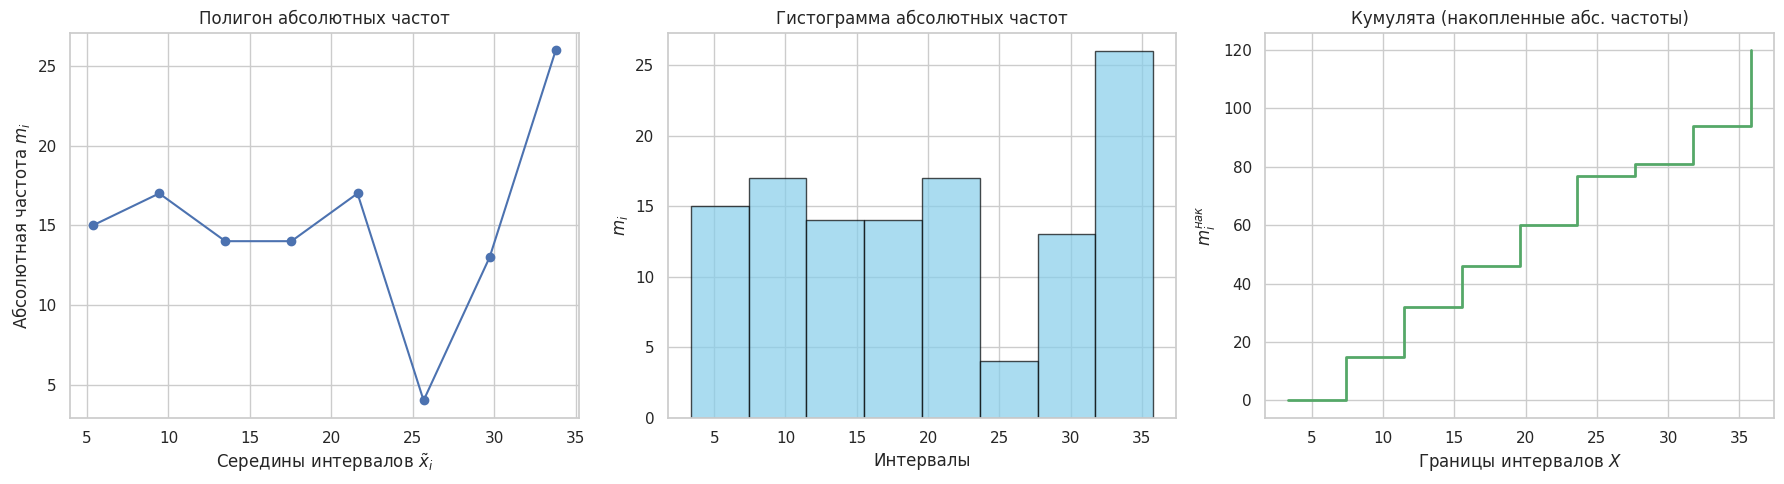

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Полигон абсолютных частот
axes[0].plot(x_tilde, m_i, marker='o', linestyle='-', color='b')
axes[0].set_title('Полигон абсолютных частот')
axes[0].set_xlabel('Середины интервалов $\\tilde{x}_i$')
axes[0].set_ylabel('Абсолютная частота $m_i$')

# Гистограмма абсолютных частот
# Ширина столбца равна шагу h, высота = m_i / h
axes[1].bar(x_tilde, m_i, width=h, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_title('Гистограмма абсолютных частот')
axes[1].set_xlabel('Интервалы')
axes[1].set_ylabel('$m_i$')

# Эмпирическая функция распределения
x_ecdf = [bins[0]] + bins[1:]
y_ecdf = [0] + list(m_i_cum)
axes[2].step(x_ecdf, y_ecdf, where='post', color='g', linewidth=2)
axes[2].set_title('Кумулята (накопленные абс. частоты)')
axes[2].set_xlabel('Границы интервалов $X$')
axes[2].set_ylabel('$m_i^{нак}$')

plt.tight_layout()
plt.show()

На основе построенных графиков абсолютных частот видно, что полигон и гистограмма позволяют оценить форму эмпирического распределения исследуемой выборки. Визуально определяется область наибольшей концентрации значений, а также оценивается симметричность распределения и разброс данных.

График эмпирической функции распределения для абсолютных частот имеет характерный ступенчатый вид, монотонно не убывает и на последнем интервале строго достигает максимального значения, равного объему выборки ($n = 120$). Это наглядно иллюстрирует процесс накопления частот на всем диапазоне варьирования признака.

### Пункт 6. Графики для относительных частот ($\tilde{m}_i$)
Повторяем построения, но используем относительные и накопленные относительные частоты. Форма графиков должна полностью совпасть с предыдущим пунктом, изменится только масштаб по оси ординат (Y).

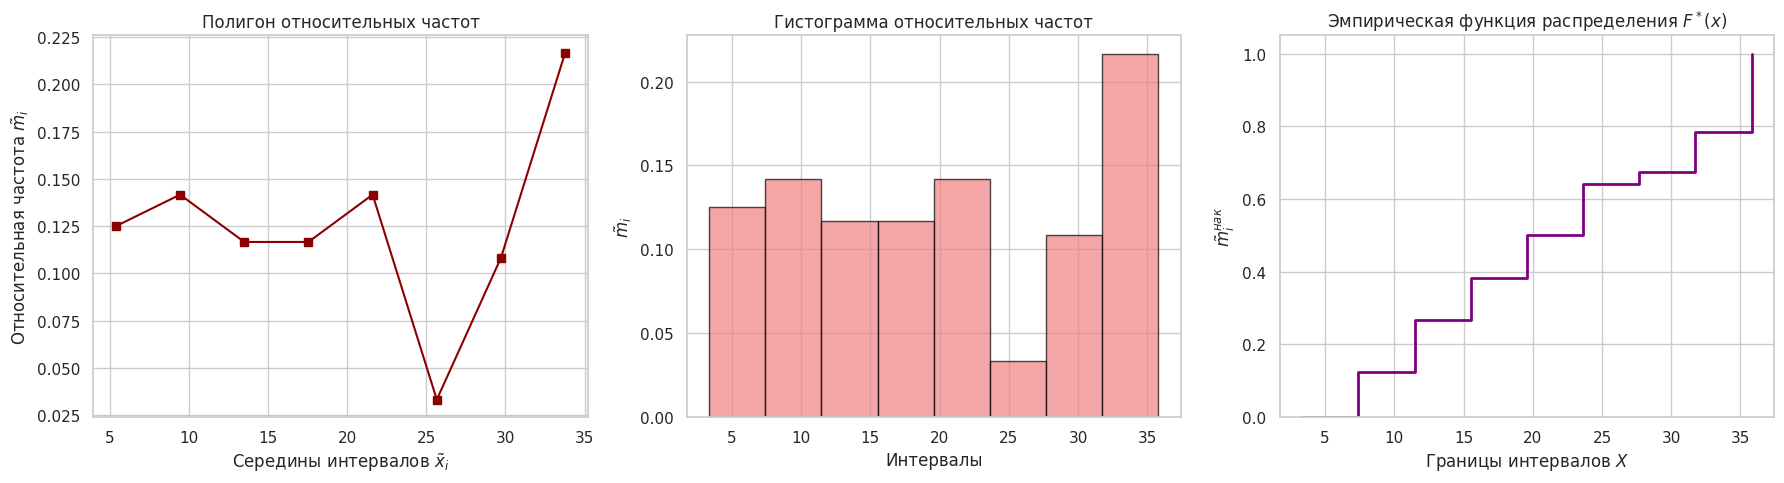

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Полигон относительных частот
axes[0].plot(x_tilde, m_i_rel, marker='s', linestyle='-', color='darkred')
axes[0].set_title('Полигон относительных частот')
axes[0].set_xlabel('Середины интервалов $\\tilde{x}_i$')
axes[0].set_ylabel('Относительная частота $\\tilde{m}_i$')

# Гистограмма относительных частот
axes[1].bar(x_tilde, m_i_rel, width=h, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_title('Гистограмма относительных частот')
axes[1].set_xlabel('Интервалы')
axes[1].set_ylabel('$\\tilde{m}_i$')

# Эмпирическая функция распределения (ЭФР)
y_ecdf_rel = [0] + list(m_i_rel_cum)
axes[2].step(x_ecdf, y_ecdf_rel, where='post', color='purple', linewidth=2)
axes[2].set_title('Эмпирическая функция распределения $F^*(x)$')
axes[2].set_xlabel('Границы интервалов $X$')
axes[2].set_ylabel('$\\tilde{m}_i^{нак}$')
axes[2].set_ylim(0, 1.05) # ЭФР стремится к 1

plt.tight_layout()
plt.show()

Сравнение графиков, построенных для абсолютных и относительных частот, демонстрирует их полную геометрическую идентичность: форма полигонов и гистограмм полностью совпадает. Единственным отличием является масштаб оси ординат — переход к относительным показателям осуществляет вероятностную нормировку данных. В результате площадь гистограммы становится равной единице, выступая выборочной оценкой плотности вероятности.

График относительных накопленных частот строго возрастает от 0 до 1, полностью удовлетворяя математическим свойствам теоретической интегральной функции распределения и являясь её состоятельной непараметрической оценкой.

### Вывод

В ходе лабораторной работы была проведена первичная статистическая обработка одномерной выборки непрерывных экспериментальных данных. Были выполнены процедуры формирования репрезентативной выборки, преобразования данных в ранжированный и интервальный ряды, а также рассчитаны абсолютные, относительные и накопленные частоты. Для визуального анализа были построены гистограммы, полигоны частот и эмпирические функции распределения.

На основе анализа полученных результатов установлено, что:

* Группировка непрерывных данных в интервальный статистический ряд позволяет устранить информационный шум индивидуальных значений и выявить скрытые закономерности варьирования признака.
* Анализ частотных характеристик подтверждает отсутствие вычислительных погрешностей и потерь данных: сумма относительных частот строго равна единице, а последняя накопленная абсолютная частота совпадает с общим объемом выборки ($n=120$).
* Визуализация рядов с помощью полигонов и гистограмм дает наглядное представление о форме распределения, модальных интервалах и дисперсии выборки.
* Переход от абсолютных частот к относительным выполняет необходимую вероятностную нормировку, при которой эмпирическая функция распределения корректно аппроксимирует теоретическую функцию распределения вероятностей, строго возрастая от 0 до 1.

Таким образом, в результате выполнения работы были приобретены практические навыки применения статистических методов группировки данных, построения интервальных рядов распределения, а также сформировано понимание вероятностного смысла частотных характеристик и графических моделей выборки.